# Brain Tumor Detection – CNN from Scratch
This notebook builds and trains a custom CNN on the brain tumor dataset.

## 1. Test Data Generator (unseen data)

In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    '../data/Testing',          # because notebook is inside 'notebooks/'
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 1600 images belonging to 4 classes.


## 2. Training & Validation Generators (from Training/ folder)

In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    '../data/Training',
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = datagen.flow_from_directory(
    '../data/Training',
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

print("Training/validation generators ready")
print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}")

Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Training/validation generators ready
Training samples: 4480
Validation samples: 1120


## 3. Build and Compile the CNN Model

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/home/alexei/brain-tumor-detection-model/venv/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1777951441.740993  436351 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1777951441.741290  436859 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1777951441.754764  436351 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,517,060 (24.86 MB)

 Trainable params: 6,517,060 (24.86 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Callbacks – Early Stopping and Model Checkpoint

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import os

os.makedirs('models', exist_ok=True)

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('models/scratch_model.keras', monitor='val_accuracy', save_best_only=True)

## 5. Train the Model

In [5]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Epoch 1/30


I0000 00:00:1777951462.539323  436351 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


140/140 ━━━━━━━━━━━━━━━━━━━━ 30s 206ms/step - accuracy: 0.6643 - loss: 0.7988 - val_accuracy: 0.8089 - val_loss: 0.5430
Epoch 2/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 30s 216ms/step - accuracy: 0.8371 - loss: 0.4486 - val_accuracy: 0.8455 - val_loss: 0.3724
Epoch 3/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 29s 209ms/step - accuracy: 0.8799 - loss: 0.3164 - val_accuracy: 0.8795 - val_loss: 0.3042
Epoch 4/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 29s 205ms/step - accuracy: 0.9185 - loss: 0.2279 - val_accuracy: 0.8723 - val_loss: 0.3059
Epoch 5/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 28s 203ms/step - accuracy: 0.9330 - loss: 0.1809 - val_accuracy: 0.9134 - val_loss: 0.2330
Epoch 6/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 30s 215ms/step - accuracy: 0.9525 - loss: 0.1273 - val_accuracy: 0.9223 - val_loss: 0.2241
Epoch 7/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 28s 201ms/step - accuracy: 0.9703 - loss: 0.0932 - val_accuracy: 0.9205 - val_loss: 0.2113
Epoch 8/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 31s 221ms/step - accuracy: 0.9737 - loss: 0.0741 - val

## 6. Evaluation on the Test Set

In [7]:
test_loss, test_acc = model.evaluate(test_generator, verbose=0)
print(f"Scratch CNN - Test accuracy: {test_acc:.4f}")

Scratch CNN - Test accuracy: 0.8681


## 7. Evaluate the Best Saved Model (Checkpoint)

In [3]:
from tensorflow.keras.models import load_model
best = load_model('models/scratch_model.keras')
test_loss, test_acc = best.evaluate(test_generator, verbose=0)
print(f"Best checkpoint model test accuracy: {test_acc:.4f}")

I0000 00:00:1777955804.366019  468925 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


Best checkpoint model test accuracy: 0.8900


## 8. Save Training History to JSON

In [4]:
import json
history_dict = {
    'accuracy': history.history['accuracy'],
    'val_accuracy': history.history['val_accuracy'],
    'loss': history.history['loss'],
    'val_loss': history.history['val_loss'],
    'best_val_acc': max(history.history['val_accuracy']),
    'best_test_acc': test_acc  # from above
}
with open('scratch_history.json', 'w') as f:
    json.dump(history_dict, f)

NameError: name 'history' is not defined

## 9. Visualise Training History (Accuracy & Loss)

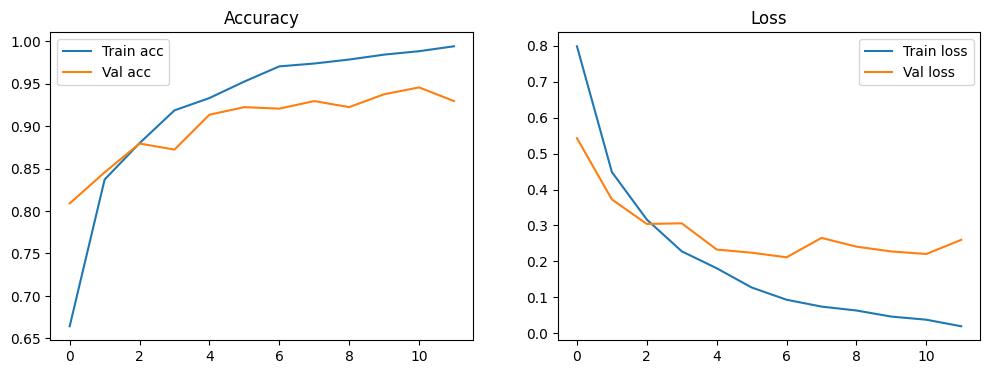

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train acc')
plt.plot(history.history['val_accuracy'], label='Val acc')
plt.title('Accuracy')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.title('Loss')
plt.legend()
plt.show()

## 10. Compare new to backed up model


In [ ]:
from tensorflow.keras.models import load_model
backup_model = load_model('models/scratch_model_backup.keras')
new_model = load_model('models/scratch_model.keras')
print("Backup test accuracy:", backup_model.evaluate(test_generator, verbose=0)[1])
print("New model test accuracy:", new_model.evaluate(test_generator, verbose=0)[1])